In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [17]:
concrete_data = pd.read_excel('/workspaces/AnaliticaDeDatos/datos/clases/clase_1_analisis_exploratorio_de_datos/Concrete_Data.xls', index_col=False)

Seleccionamos el predictor y el predictando

In [18]:
columnas = concrete_data.columns
print('Mis variables son :', columnas)

Mis variables son : Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='str')


In [19]:
predictor = concrete_data[columnas[0]]
predictando = concrete_data[columnas[-1]]

Visualizamos la posible relación entre nuestos datos

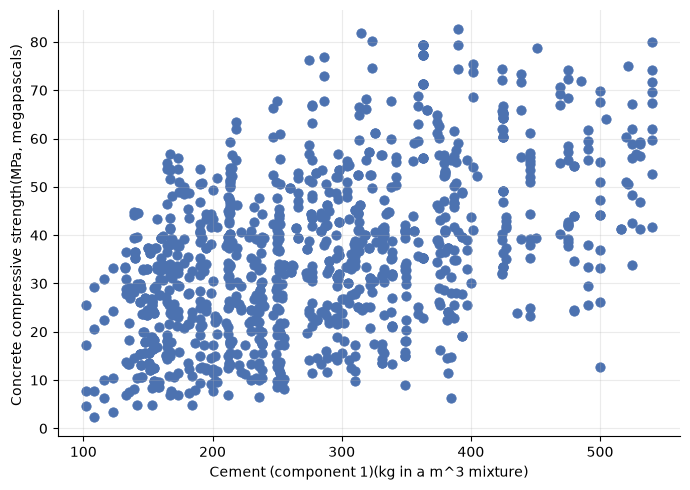

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(predictor, predictando, color="#4C72B0", linewidth=0.6, s=45)
ax.set_xlabel(columnas[0])
ax.set_ylabel(columnas[-1])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Vamos a aplicar un modelo de regresión lineal simple

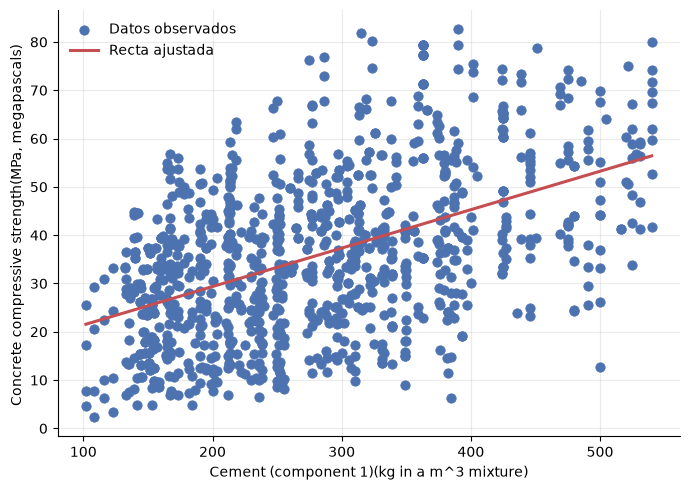

In [29]:
pendiente, intercepto = np.polyfit(predictor, predictando, 1)

yhat = intercepto + pendiente * predictor
scr = np.sum((predictando - yhat)**2)
sct = np.sum((predictando - predictando.mean())**2)
r2 = 1 - scr / sct

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(predictor, predictando, color="#4C72B0", linewidth=0.6, s=45, label="Datos observados", zorder=2)

xx = np.linspace(predictor.min(), predictor.max(), 100)
ax.plot(xx, intercepto + pendiente * xx, color="#C44E52", linewidth=2.2,
        label="Recta ajustada", zorder=3)

ax.set_xlabel(columnas[0])
ax.set_ylabel(columnas[-1])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.25)
ax.legend(loc="best", frameon=False)
plt.tight_layout()
plt.show()